In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

import sys
import time
from Bio import Entrez

In [2]:
abundance_table = pd.read_excel('../data/abundance_table.xlsx')
table_with_RUG = pd.read_csv('../data/mags_metadata.tsv', sep='\t')

In [3]:
clusters = pd.read_csv("../data/final_table.csv")

def extract_gca(text):
    match = re.search(r'GCA_\d+\.\d+', str(text))
    return match.group(0)

clusters['Assembly'] = clusters['target'].apply(extract_gca)

# Только репрезентативные локусы
clusters_filtered = clusters[clusters["SQ_score"].isin(["min_up", "min_down", "max"])].copy()

## RUG normalization

In [18]:
df_RUG = abundance_table.copy()

In [20]:
sample_columns = df_RUG.columns[4:286].tolist()
len(sample_columns)

282

In [21]:
# Нормализация на TotalDepth
RUG_norm = df_RUG[sample_columns].div(df_RUG['TotalDepth'], axis=0)
df_RUG['Abundance'] = RUG_norm.mean(axis=1)

df_RUG.drop(df_RUG.columns[1:292], axis=1, inplace=True)
abundance_RUG = pd.merge(table_with_RUG, df_RUG, on='RUG', how='left')
abundance_RUG_clusters = pd.merge(clusters_filtered, abundance_RUG, on='Assembly', how='left')

In [22]:
# Разделяем taxonomy по ; и создаем новые колонки
taxonomy_split = abundance_RUG_clusters['taxonomy'].str.split(';', expand=True)

# Присваиваем значения соответствующим колонкам
abundance_RUG_clusters['kingdom'] = taxonomy_split[0]  # d__Bacteria
abundance_RUG_clusters['phylum'] = taxonomy_split[1]   # p__Bacillota
abundance_RUG_clusters['class'] = taxonomy_split[2]    # c__Clostridia
abundance_RUG_clusters['order'] = taxonomy_split[3]    # o__Oscillospirales
abundance_RUG_clusters['family'] = taxonomy_split[4]   # f__Oscillospiraceae
abundance_RUG_clusters['genus'] = taxonomy_split[5]    # g__CAG-103
abundance_RUG_clusters['species'] = taxonomy_split[6]  # s__CAG-103 sp900317905
abundance_RUG_clusters

taxonomy_cols = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
for col in taxonomy_cols:
    abundance_RUG_clusters[col] = abundance_RUG_clusters[col].str.replace(r'^[a-z]__', '', regex=True)

abundance_RUG_clusters.drop(abundance_RUG_clusters.columns[[1, 6, 7, 8, 10, 11, 12, 13]], axis=1, inplace=True)
abundance_RUG_clusters

,cluster,contig,SQ_gene_content_set,SQ_pathway,SQ_score,Assembly,RUG,Abundance,kingdom,phylum,class,order,family,genus,species
0,66,CACVLH010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,GCA_902754915.1,RUG10005,0.003546,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
1,392,CACVNO010000004.1,"sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,GCA_902755455.1,RUG10063,0.003546,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Limivicinus,Limivicinus sp900319635
2,445,CACVNV010000015.1,"sedA,slaB,sqiA,squF,sqvD,yihV",sulfo-EMP,max,GCA_902755505.1,RUG10071,0.003546,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,Faecalimonas,Faecalimonas sp900316755
3,584,CACVOI010000078.1,"sqvA,sqvB,sqvD,yihQ",sulfo-TAL,min_up,GCA_902755725.1,RUG10098,0.003546,Bacteria,Bacillota,Clostridia,Oscillospirales,Acutalibacteraceae,Eubacterium_R,Eubacterium_R sp900316345
4,603,CACVOP010000002.1,"sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,GCA_902755775.1,RUG10095,0.003546,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Limivicinus,Limivicinus sp900320465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,37800,CADCQZ010000219.1,"sedA,slaB,sqiA,squF,sqvD,yihV",sulfo-EMP,max,GCA_902803675.1,RUG14898,0.003546,Bacteria,Bacillota,Clostridia,Christensenellales,Aristaeellaceae,RUG756,RUG756 sp902782865
149,37807,CADCQZ010000306.1,"sqiA,sqvD,yihV",sulfo-EMP,min_up,GCA_902803675.1,RUG14898,0.003546,Bacteria,Bacillota,Clostridia,Christensenellales,Aristaeellaceae,RUG756,RUG756 sp902782865
150,38001,CADCRR010000005.1,"sqvA,sqvB,sqvD,yihQ,yihU",sulfo-TAL,max,GCA_902803825.1,RUG14918,0.003546,Bacteria,Bacillota,Clostridia,Oscillospirales,Acutalibacteraceae,UBA1081,UBA1081 sp900314355
151,38167,CADCSF010000148.1,"sqvA,sqvB,sqvD",sulfo-TAL,min_up,GCA_902804025.1,RUG14938,0.003546,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,Anthropogastromicrobium,Anthropogastromicrobium sp900315495


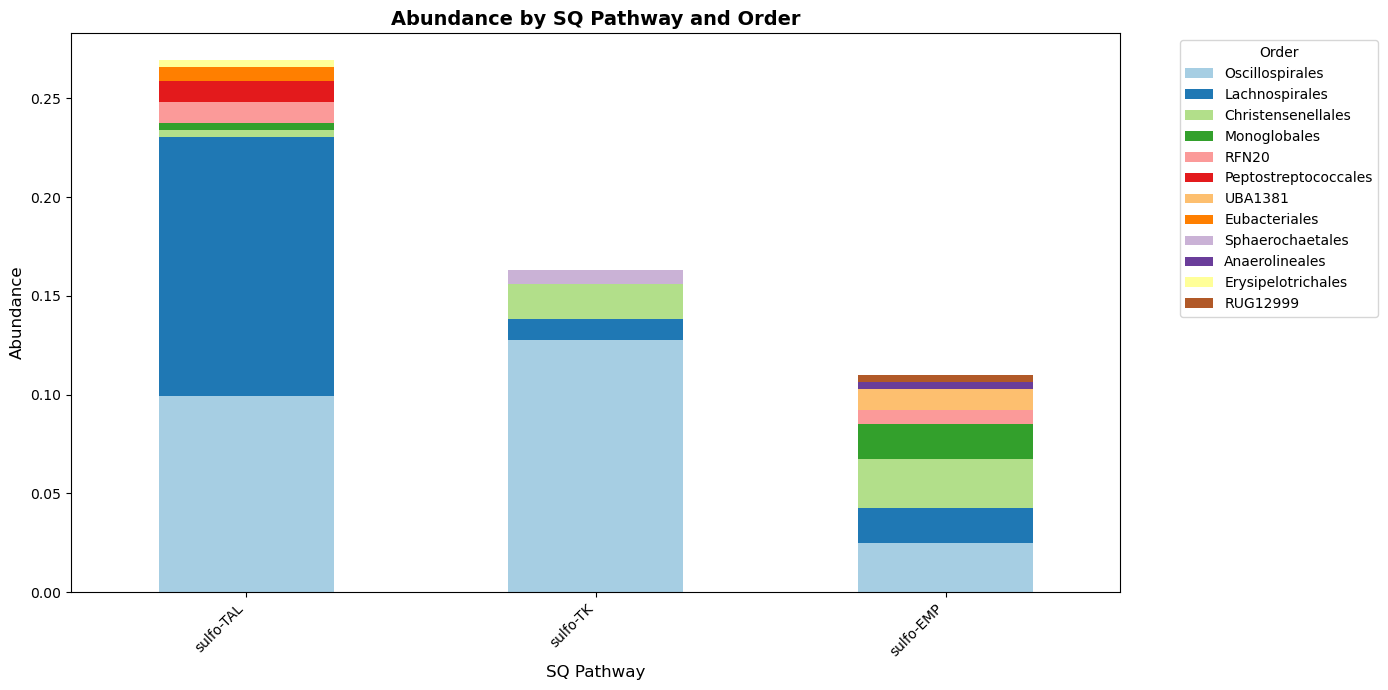

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

new_df_RUG = abundance_RUG_clusters.copy()
# 1. Подготовка данных: создаем сводную таблицу
pivot_df = new_df_RUG.pivot_table(
    index='SQ_pathway', 
    columns='order', 
    values='Abundance', 
    aggfunc='sum'
).fillna(0)

# 2. Сортировка СТОЛБЦОВ (классы в легенде и слои в барах)
col_order = pivot_df.sum(axis=0).sort_values(ascending=False).index
pivot_df = pivot_df[col_order]

# 3. Сортировка СТРОК (высота столбцов на графике)
row_order = pivot_df.sum(axis=1).sort_values(ascending=False).index
pivot_df = pivot_df.reindex(row_order)

# 4. Построение графика
ax = pivot_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 7), # Немного увеличили ширину для читаемости
    colormap='Paired'
)

# 5. Настройка оформления
plt.title('Abundance by SQ Pathway and Order', fontsize=14, fontweight='bold')
plt.xlabel('SQ Pathway', fontsize=12)
plt.ylabel('Abundance', fontsize=12)

# Вынос легенды за пределы графика
plt.legend(title='Order', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Поворот подписей оси X для лучшей читаемости
plt.xticks(rotation=45, ha='right')

# Автоматическая подгонка размеров, чтобы ничего не обрезалось
plt.tight_layout()

plt.savefig('../pictures/abundance_plot.png', dpi=300, bbox_inches='tight')

plt.show()


In [30]:
# 1. Группируем и суммируем
class_pathway_abundance = new_df_RUG.groupby(['order', 'SQ_pathway'])['Abundance'].sum().reset_index()

# 2. Сортируем по убыванию важности
class_pathway_abundance = class_pathway_abundance.sort_values('Abundance', ascending=False)

class_pathway_abundance

,order,SQ_pathway,Abundance
7,Lachnospirales,sulfo-TAL,0.131206
13,Oscillospirales,sulfo-TK,0.127660
12,Oscillospirales,sulfo-TAL,0.099291
11,Oscillospirales,sulfo-EMP,0.024823
1,Christensenellales,sulfo-EMP,0.024823
9,Monoglobales,sulfo-EMP,0.017730
3,Christensenellales,sulfo-TK,0.017730
6,Lachnospirales,sulfo-EMP,0.017730
14,Peptostreptococcales,sulfo-TAL,0.010638
16,RFN20,sulfo-TAL,0.010638


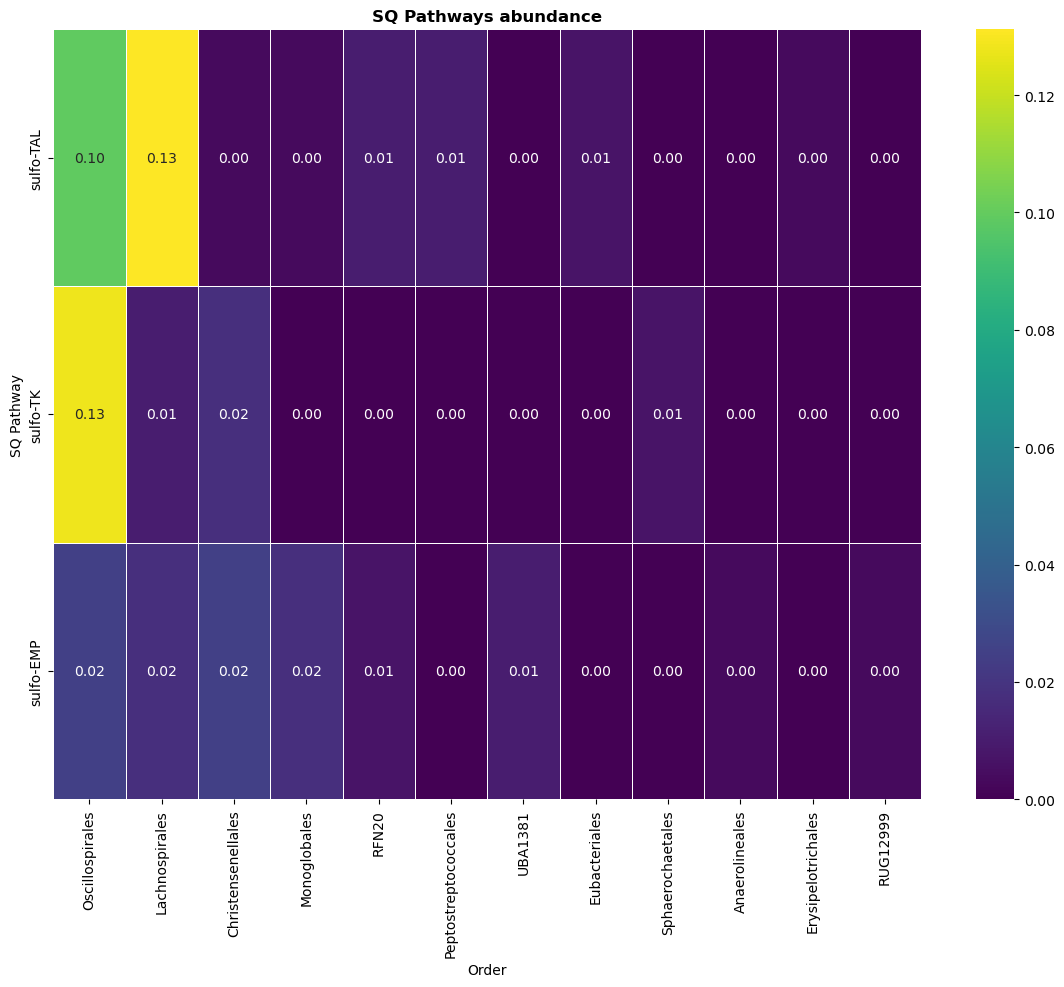

In [31]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot_df, 
    cmap='viridis', 
    annot=True,        # Вывод числовых значений
    fmt=".2f",         # Округление до 2 знаков
    linewidths=.5      # Тонкие линии между ячейками
)

plt.title('SQ Pathways abundance', fontweight='bold')
plt.ylabel('SQ Pathway')
plt.xlabel('Order')
plt.show()
